In [1]:
from PIL import Image
import requests
import io
import math
import matplotlib.pyplot as plt
# %config InlineBackend.figure_format = 'retina'

import torch
from torch import nn
from torchvision.models import resnet50
import torchvision.transforms as T
import numpy
torch.set_grad_enabled(False);

In [2]:
# ! pip install git+https://github.com/cocodataset/panopticapi.git


In [3]:
import panopticapi
from panopticapi.utils import id2rgb, rgb2id

In [4]:
# These are the COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# Detectron2 uses a different numbering scheme, we build a conversion table
coco2d2 = {}
count = 0
for i, c in enumerate(CLASSES):
  if c != "N/A":
    coco2d2[i] = count
    count+=1

# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



In [5]:
model, postprocessor = torch.hub.load('facebookresearch/detr', 'detr_resnet101_panoptic', pretrained=True, return_postprocessor=True, num_classes=250)
model.eval();

Using cache found in /home/anhvth/.cache/torch/hub/facebookresearch_detr_master


In [6]:
url = "http://images.cocodataset.org/val2017/000000281759.jpg"
# im = Image.open(requests.get(url, stream=True).raw)

In [7]:
im = Image.open('/mnt/share/bid-data/img_test/autopilot_test_0001_20101230_034910_000286.png')

In [8]:
# mean-std normalize the input image (batch-size: 1)
img = transform(im).unsqueeze(0)
out = model(img)

In [9]:
# m = (mask-mask.min())
# m = m/m.max()

In [10]:
# show(m, dpi=50)

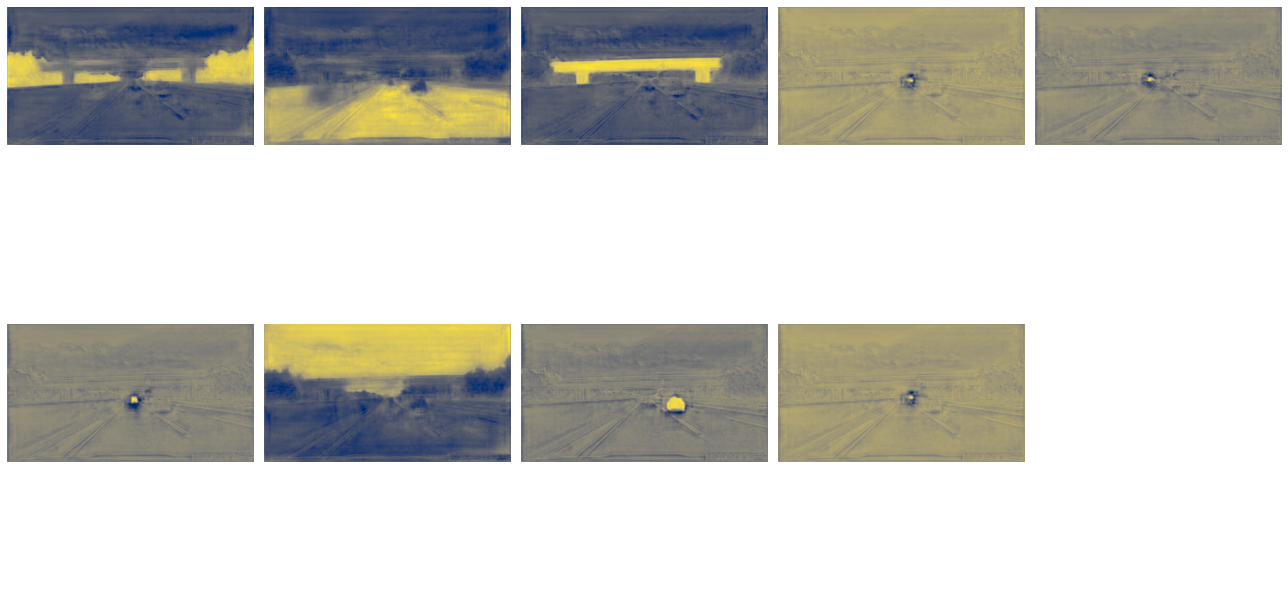

In [11]:
# compute the scores, excluding the "no-object" class (the last one)
scores = out["pred_logits"].softmax(-1)[..., :-1].max(-1)[0]
# threshold the confidence
keep = scores > 0.85

# Plot all the remaining masks
ncols = 5
fig, axs = plt.subplots(ncols=ncols, nrows=math.ceil(keep.sum().item() / ncols), figsize=(18, 10))
for line in axs:
    for a in line:
        a.axis('off')
for i, mask in enumerate(out["pred_masks"][keep]):
    ax = axs[i // ncols, i % ncols]
    ax.imshow(mask, cmap="cividis")
    ax.axis('off')
fig.tight_layout()

In [12]:
# from avcv.utils import *

In [13]:
# print_source(postprocessor.__call__)

In [14]:
# the post-processor expects as input the target size of the predictions (which we set here to the image size)
result = postprocessor(out, torch.as_tensor(img.shape[-2:]).unsqueeze(0))[0]

/home/anhvth/miniconda3/lib/python3.8/site-packages/torch/nn/functional.py:2970: UserWarning: Default upsampling behavior when mode=bilinear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  warnings.warn("Default upsampling behavior when mode={} is changed "


In [15]:
from avcv.utils import *
print_source(rgb2id)

def rgb2id(color):
    if isinstance(color, np.ndarray) and len(color.shape) == 3:
        if color.dtype == np.uint8:
            color = color.astype(np.int32)
        return color[:, :, 0] + 256 * color[:, :, 1] + 256 * 256 * color[:, :, 2]
    return int(color[0] + 256 * color[1] + 256 * 256 * color[2])

---- Define in:
/home/anhvth/miniconda3/lib/python3.8/site-packages/panopticapi/utils.py: 73


In [16]:
import itertools
import seaborn as sns
palette = itertools.cycle(sns.color_palette())

# The segmentation is stored in a special-format png
panoptic_seg = Image.open(io.BytesIO(result['png_string']))
panoptic_seg = numpy.array(panoptic_seg, dtype=numpy.uint8).copy()
panoptic_seg_id = rgb2id(panoptic_seg)


In [17]:
panoptic_seg_id

array([[5, 5, 5, ..., 5, 5, 5],
       [5, 5, 5, ..., 5, 5, 5],
       [5, 5, 5, ..., 5, 5, 5],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=int32)

In [18]:
panoptic_seg_id.shape

(800, 1422)

In [19]:
# panoptic_seg_id

In [20]:
panoptic_seg

array([[[5, 0, 0],
        [5, 0, 0],
        [5, 0, 0],
        ...,
        [5, 0, 0],
        [5, 0, 0],
        [5, 0, 0]],

       [[5, 0, 0],
        [5, 0, 0],
        [5, 0, 0],
        ...,
        [5, 0, 0],
        [5, 0, 0],
        [5, 0, 0]],

       [[5, 0, 0],
        [5, 0, 0],
        [5, 0, 0],
        ...,
        [5, 0, 0],
        [5, 0, 0],
        [5, 0, 0]],

       ...,

       [[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        ...,
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        ...,
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        ...,
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]]], dtype=uint8)

In [21]:
from avcv.vision import *

In [22]:
np.unique(panoptic_seg_id)

array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32)

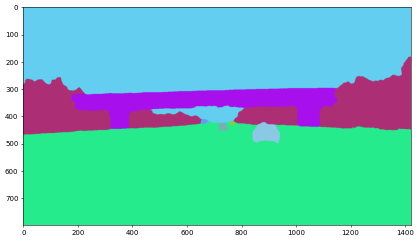

In [23]:
show(gt_to_color_mask(panoptic_seg_id), dpi=50)

In [24]:
panoptic_seg

array([[[5, 0, 0],
        [5, 0, 0],
        [5, 0, 0],
        ...,
        [5, 0, 0],
        [5, 0, 0],
        [5, 0, 0]],

       [[5, 0, 0],
        [5, 0, 0],
        [5, 0, 0],
        ...,
        [5, 0, 0],
        [5, 0, 0],
        [5, 0, 0]],

       [[5, 0, 0],
        [5, 0, 0],
        [5, 0, 0],
        ...,
        [5, 0, 0],
        [5, 0, 0],
        [5, 0, 0]],

       ...,

       [[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        ...,
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        ...,
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]],

       [[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        ...,
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]]], dtype=uint8)

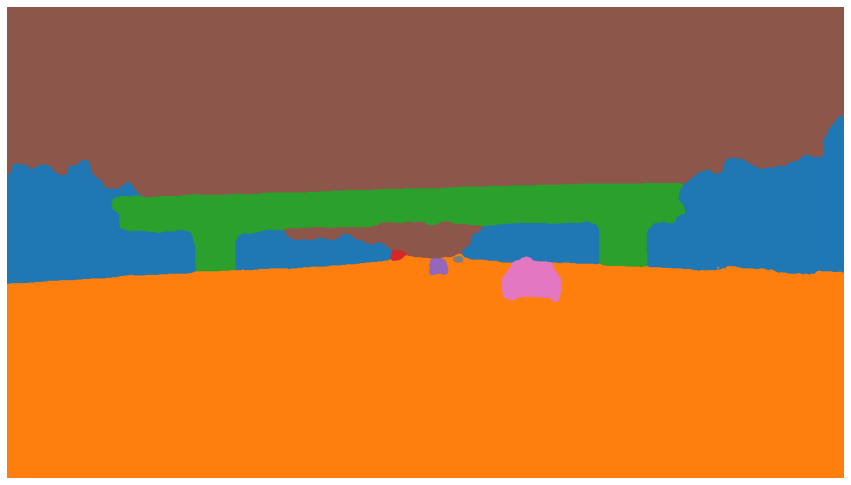

In [25]:

# We retrieve the ids corresponding to each mask
# panoptic_seg_id = rgb2id(panoptic_seg)

# Finally we color each mask individually
panoptic_seg[:, :, :] = 0
for id in range(panoptic_seg_id.max() + 1):
    panoptic_seg[panoptic_seg_id == id] = numpy.asarray(next(palette)) * 255
plt.figure(figsize=(15,15))
plt.imshow(panoptic_seg)
plt.axis('off')
plt.show()

In [ ]:
# !pip install detectron2==0.1.3 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu101/torch1.5/index.html
# from detectron2.config import get_cfg
# from detectron2.utils.visualizer import Visualizer
# from detectron2.data import MetadataCatalog
# # from google.colab.patches import cv2_imshow

In [28]:
# from detectron2.data import MetadataCatalog

In [29]:
# from copy import deepcopy
# # We extract the segments info and the panoptic result from DETR's prediction
# segments_info = deepcopy(result["segments_info"])
# # Panoptic predictions are stored in a special format png
# panoptic_seg = Image.open(io.BytesIO(result['png_string']))
# final_w, final_h = panoptic_seg.size
# # We convert the png into an segment id map
# panoptic_seg = numpy.array(panoptic_seg, dtype=numpy.uint8)
# panoptic_seg = torch.from_numpy(rgb2id(panoptic_seg))

    
    
# # Detectron2 uses a different numbering of coco classes, here we convert the class ids accordingly
# 
# for i in range(len(segments_info)):
#     c = segments_info[i]["category_id"]
#     segments_info[i]["category_id"] = meta.thing_dataset_id_to_contiguous_id[c] if segments_info[i]["isthing"] else meta.stuff_dataset_id_to_contiguous_id[c]


# # Finally we visualize the prediction
# v = Visualizer(numpy.array(im.copy().resize((final_w, final_h)))[:, :, ::-1], meta, scale=1.0)
# v._default_font_size = 20
# vis = v.draw_panoptic_seg_predictions(panoptic_seg, segments_info, area_threshold=0)
# show(vis.get_image(), dpi=100)

In [58]:
with open('coco_panoptic_meta.json', 'w') as f:
    json.dump(meta.__dict__, f)

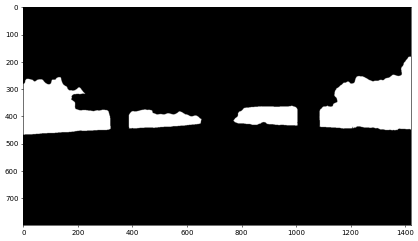

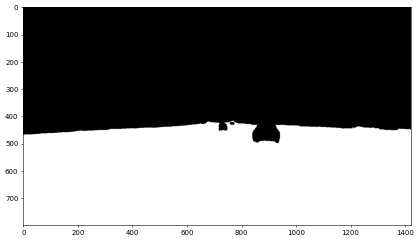

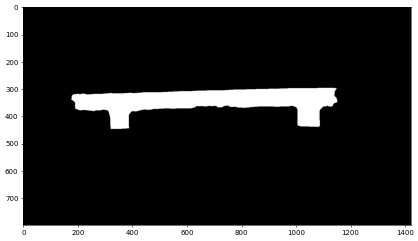

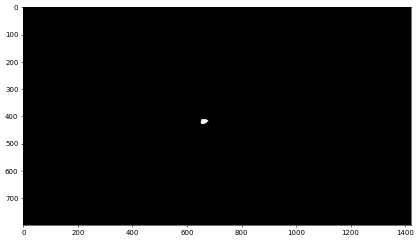

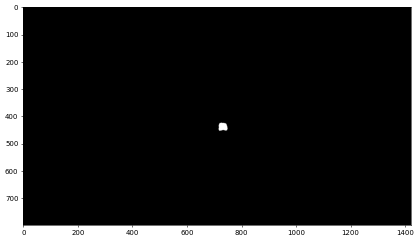

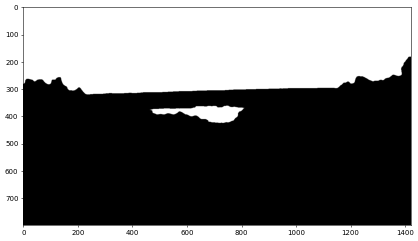

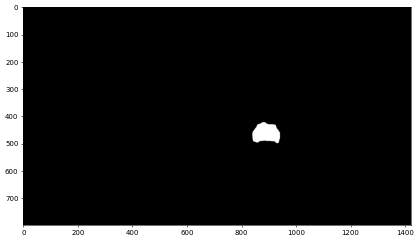

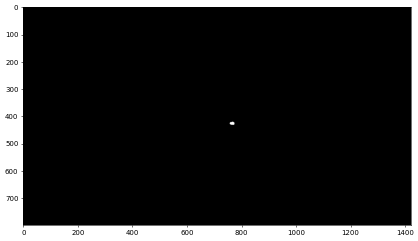

In [64]:
meta = read_json("coco_panoptic_meta.json")

instance_ids = np.unique(panoptic_seg_id)
segments_info = result["segments_info"]

for instance_id, info in zip(instance_ids, segments_info):
    if not info['isthing']:
        cate = meta['stuff_dataset_id_to_contiguous_id'][str(info['category_id'])]
        name = meta['stuff_classes'][cate]
    else:
        cate = meta['thing_dataset_id_to_contiguous_id'][str(info['category_id'])]
        name = meta['thing_classes'][cate]
    info['class_name'] = name
    instance_mask = panoptic_seg_id == instance_id
    show(instance_mask, dpi=50)
